<a href="https://colab.research.google.com/github/vishalrathod7453/Supply-Chain-Analysis/blob/main/Data_Analysis_Pro_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supply Chain Data Analysis and Prediction

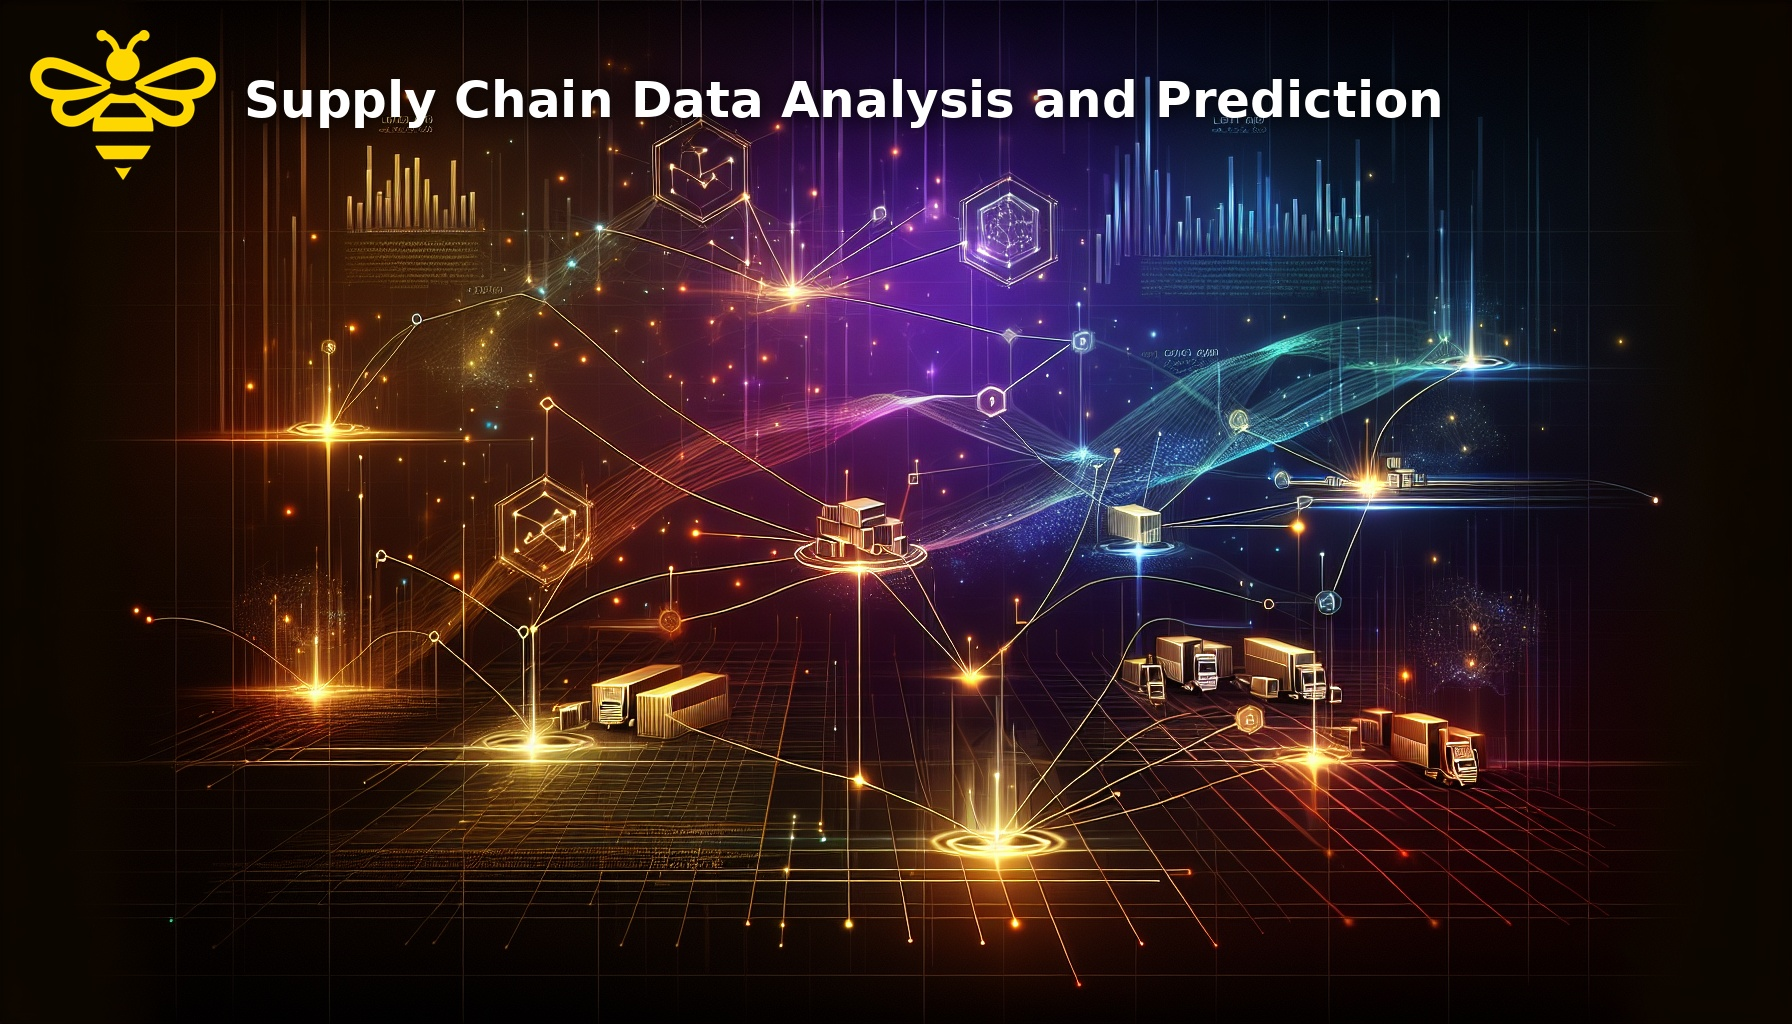

# Introduction
Supply chain data is full of surprises when you start peeling back the layers. Our analysis today will take a deep dive into various supply chain metrics to uncover insights that might help streamline operations. If you find this notebook useful, please consider upvoting it. Let's get curious and see what the numbers reveal.

# Step 1 ) Import Library
   - pandas, numpy, Matplotlib, seaborn
       

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2) Dataset load From kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("litonislam/supply-chain-data-analysis")

print("Path to dataset files:", path)

In [ ]:
df= pd.read_csv(f'{path}/supply_chain_data.csv')


# 3) Dataset Preprocess

In [ ]:
# Check Top Rows in dataset
df.head()

In [ ]:
# check the dataset Size
df.shape

In [ ]:
# Dataset Description
df.describe()

In [ ]:
# Check dataset information
df.info()

In [ ]:
df.columns

In [ ]:
df.dtypes

#step 4) Dataset cleaning Proceses

In [ ]:
# Check Dublicated Records
df.duplicated().sum()

In [ ]:
# check null records
df.isnull().sum()

In [ ]:

# Check the Outlir in All dataset
plt.figure(figsize=(15,5))
sns.boxplot(data =df)
plt.show()

# step 6) Perform to Data visualization (EDA)

In [ ]:
from pandas.core.arrays import numeric


In [ ]:
# Numeric dataframe for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# Correlation heatmap (only if numeric columns are 4 or more)
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()
else:
    print('Not enough numeric columns for a heatmap.')






In [ ]:
# Pair Plot to examine relationships among key numeric variables
key_vars = ['Price', 'Revenue generated', 'Number of products sold', 'Shipping costs']
present_vars = [col for col in key_vars if col in df.columns]
if len(present_vars) >= 2:
    sns.pairplot(df[present_vars].dropna())
    plt.suptitle('Pair Plot of Key Numeric Variables', y=1.02)
    plt.show()
else:
    print('Not enough key variables available for pair plot.')

In [ ]:
# Histogram for distribution of Price
if 'Price' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df['Price'].dropna(), kde=True, color='skyblue')
    plt.title('Distribution of Price')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
# Count plot for Product type (appears to be categorical)
if 'Product type' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='Product type', hue='Product type', palette='viridis', legend=False)
    plt.title('Count Plot of Product Types')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Box plot for Shipping costs to detect outliers
if 'Shipping costs' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df['Shipping costs'].dropna(), color='lightgreen')
    plt.title('Box Plot of Shipping Costs')
    plt.ylabel('Shipping Costs')
    plt.show()

## Saving Images

To save a plot or figure generated with `matplotlib` (which `seaborn` uses internally), you can use the `plt.savefig()` function. This function allows you to save the current figure to a file in various formats (e.g., PNG, JPEG, PDF, SVG).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dummy plot for demonstration
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Shipping costs'].dropna(), color='lightgreen')
plt.title('Box Plot of Shipping Costs (Example Save)')
plt.ylabel('Shipping Costs')

# Save the plot to a file
plt.savefig('/content/shipping_costs_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()

# You can then download the file
from google.colab import files
files.download('/content/shipping_costs_boxplot.png')

#Predictive Modeling

In a twist of supply chain fate, we explore the possibility of predicting the revenue generated based on several numeric factors. This could provide an edge in inventory and sales planning. We will use a linear regression model, splitting the data into training and testing sets, and then evaluate the model using the R² score and Mean Squared Error (MSE).



Import Machine Learning Library

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
required_cols = ['Price', 'Number of products sold', 'Shipping costs', 'Defect rates', 'Revenue generated']
present_required = [col for col in required_cols if col in df.columns]

if len(present_required) < len(required_cols):
    print('Not all required columns are present for prediction. Found:', present_required)
else:
    # Define features and target variable
    X = df[['Price', 'Number of products sold', 'Shipping costs', 'Defect rates']].fillna(0)
    y = df['Revenue generated'].fillna(0)

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create the Model
model =LinearRegression()

In [ ]:
# Train Model
model.fit(X_train, y_train)

In [ ]:
# Predict Dataset
y_pred = model.predict(X_test)

In [ ]:

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print('Model Evaluation Metrics:')
print('R2 Score:', r2)
print('Mean Squared Error:', mse)


In [ ]:
# Plotting Predicted vs Actual values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='coral')
plt.xlabel('Actual Revenue Generated')
plt.ylabel('Predicted Revenue Generated')
plt.title('Actual vs Predicted Revenue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

# Conclusions and Future Work
Our analysis has taken us through initial data loading, cleaning, visualization, and even into the realm of prediction. The linear regression model provides a basic predictive framework for revenue based on a few key supply chain metrics. While the model shows promise, further refinements could include more sophisticated feature engineering, adding interaction terms, or even exploring non-linear models like random forests.

Future work could also analyze the impact of logistical factors like lead times and shipping times, or deepen the explorations into the differences in customer demographics. The journey through supply chain data is never truly complete, and every answer uncovers more questions.

If you have found this notebook useful, please consider upvoting it.

In [ ]:
from google.colab import files

# Save the DataFrame to a CSV file before downloading
df.to_csv('Supply Chain Data Analysis and Prediction.csv', index=False)

files.download('Supply Chain Data Analysis and Prediction.csv')